# EDA Pollen & Météo — Analyse Complète 2021-2026
**Projet Antihistaminiques France — Jedha 2026**

## Sources
- **Pollen RNSA** (2021-2022) — mesures physiques par station
- **Pollen CAMS** (2023-2026) — modélisation spatiale Copernicus 0.1°
- **Météo Open-Meteo** (2021-2026) — ERA5 — 13 régions AASQA

## Plan
1. Chargement & aperçu
2. Evolution temporelle 2021-2026 — RNSA vs CAMS
3. Saisonnalité par mois
4. Carte France 13 régions
5. Corrélation météo / pollen
6. Random Forest Regressor — avec météo
7. Analyse 2024 — saison atypique
8. Synthèse

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df_pollen = pd.read_csv('/Users/nellyta/Jedha/data/silver/J0_silver_pollen_2021_2026.csv')
df_meteo  = pd.read_csv('/Users/nellyta/Jedha/data/silver/J0_silver_meteo_openmeteo_2021_2026.csv')

df_pollen['date'] = pd.to_datetime(df_pollen['date'])
df_meteo['time']  = pd.to_datetime(df_meteo['time'], format='mixed')
df_meteo['time']  = df_meteo['time'].dt.normalize()

pollen_daily = df_pollen.groupby(['date','source']).agg(
    graminees=('graminees_conc','mean'),
    bouleau=('bouleau_conc','mean'),
    aulne=('aulne_conc','mean'),
    ambroisie=('ambroisie_conc','mean'),
    armoise=('armoise_conc','mean'),
    olivier=('olivier_conc','mean')
).reset_index()

pollen_daily['mois']             = pollen_daily['date'].dt.month
pollen_daily['annee']            = pollen_daily['date'].dt.year
pollen_daily['jour_annee']       = pollen_daily['date'].dt.dayofyear
pollen_daily['saison_allergies'] = pollen_daily['mois'].apply(lambda m: 1 if m in [4,5,6,7] else 0)
pollen_daily['source_encoded']   = (pollen_daily['source'] == 'CAMS').astype(int)

meteo_daily = df_meteo.groupby('time').agg(
    temp_moy=('temperature_2m_mean','mean'),
    temp_max=('temperature_2m_max','mean'),
    temp_min=('temperature_2m_min','mean'),
    precip=('precipitation_sum','mean'),
    wind=('wind_speed_10m_max','mean')
).reset_index().rename(columns={'time':'date'})

merged = pollen_daily.merge(meteo_daily, on='date', how='left')

mois_noms  = {1:'Jan',2:'Fev',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
              7:'Jul',8:'Aou',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
colors_src = {'RNSA':'gray','CAMS':'green'}
taxons_list = ['graminees','bouleau','aulne','ambroisie','armoise','olivier']

print(f'Pollen   : {pollen_daily.shape} | Sources : {pollen_daily.source.value_counts().to_dict()}')
print(f'Meteo    : {meteo_daily.shape}')
print(f'Fusionne : {merged.shape}')
print(f'Periode  : {merged.date.min().date()} -> {merged.date.max().date()}')

Pollen   : (1751, 13) | Sources : {'CAMS': 1021, 'RNSA': 730}
Meteo    : (1977, 6)
Fusionne : (1751, 18)
Periode  : 2021-01-01 -> 2026-06-01


## 1. Evolution temporelle 2021-2026 — RNSA vs CAMS
> Pointillés = RNSA (2021-2022) / Trait plein = CAMS (2023-2026) / Zone grisée = période RNSA

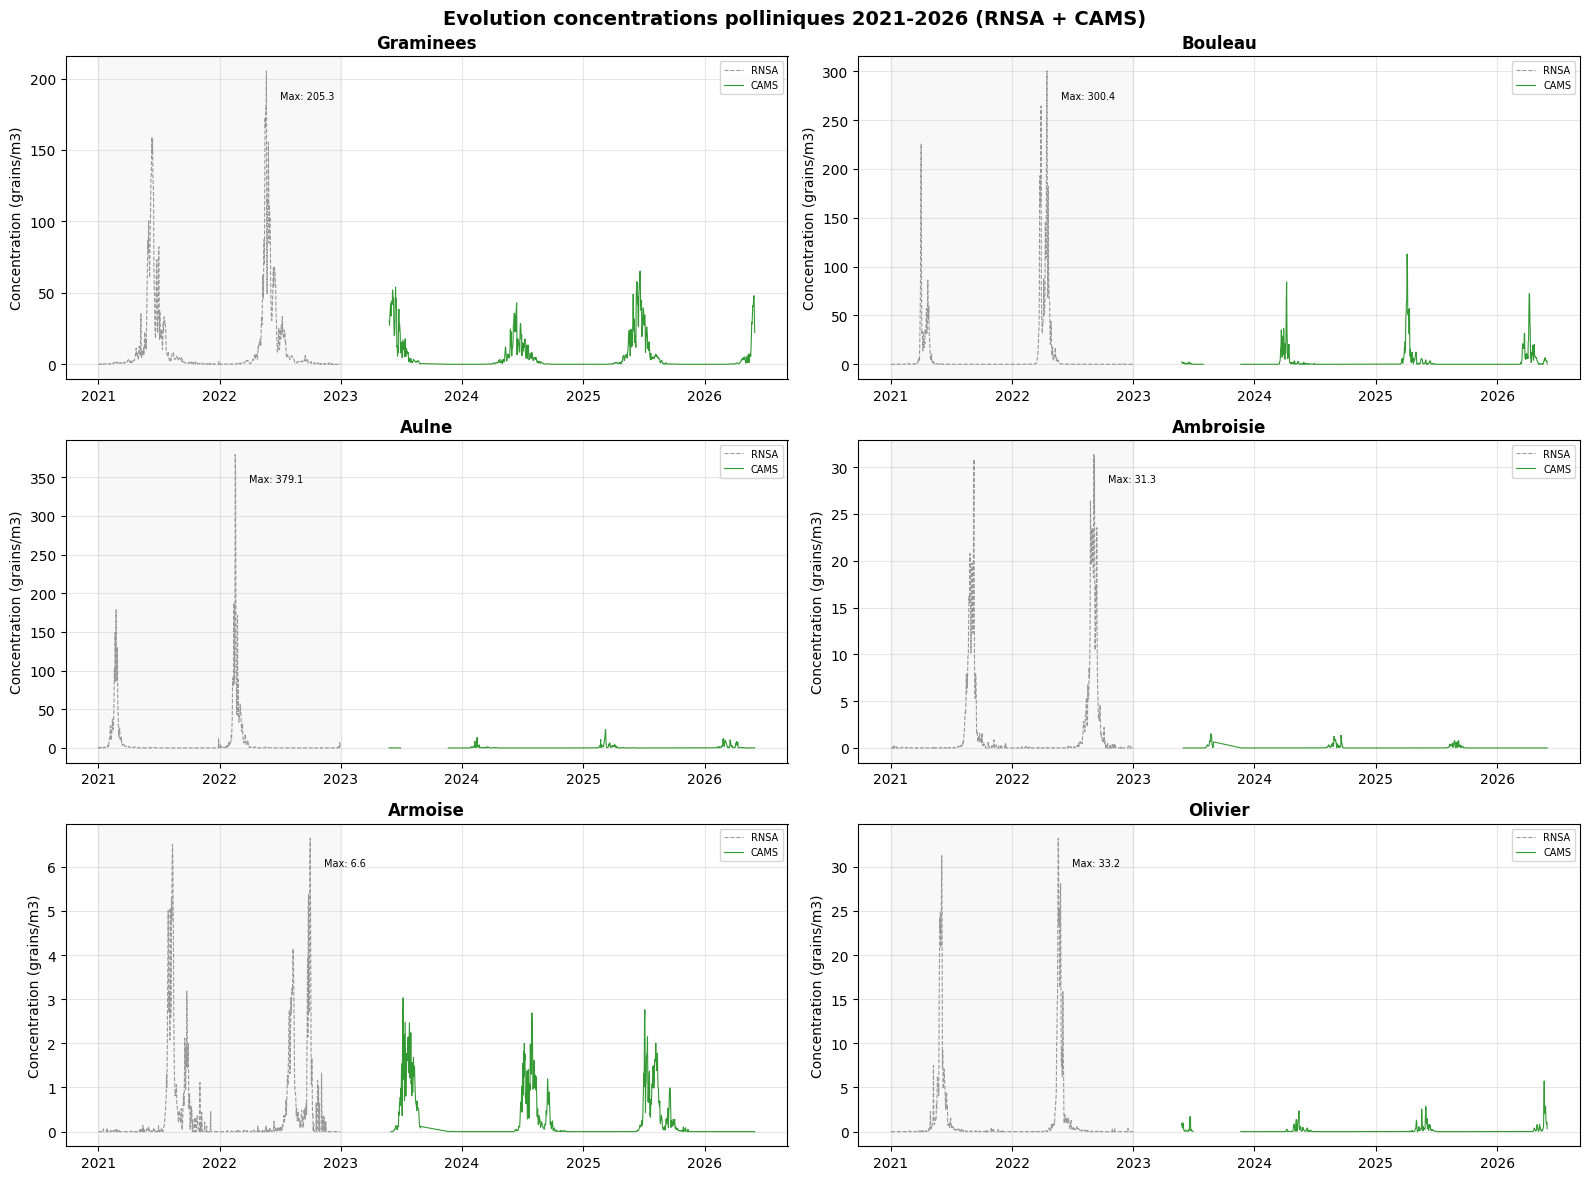

In [2]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Evolution concentrations polliniques 2021-2026 (RNSA + CAMS)',
             fontsize=14, fontweight='bold')

taxons_axes = {
    'graminees':('Graminees',axes[0,0]),'bouleau':('Bouleau',axes[0,1]),
    'aulne':('Aulne',axes[1,0]),'ambroisie':('Ambroisie',axes[1,1]),
    'armoise':('Armoise',axes[2,0]),'olivier':('Olivier',axes[2,1]),
}

for col, (label, ax) in taxons_axes.items():
    for source in ['RNSA','CAMS']:
        df_s = pollen_daily[pollen_daily['source']==source]
        ax.plot(df_s['date'], df_s[col], color=colors_src[source],
                linewidth=0.8, linestyle='--' if source=='RNSA' else '-',
                label=source, alpha=0.8)
    ax.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-31'), alpha=0.05, color='gray')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Concentration (grains/m3)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
    max_val  = pollen_daily[col].max()
    max_date = pollen_daily.loc[pollen_daily[col].idxmax(),'date']
    ax.annotate(f'Max: {max_val:.1f}', xy=(max_date, max_val),
                xytext=(10,-20), textcoords='offset points', fontsize=7)

plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/pollen_evolution_complet.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Saisonnalite par mois — RNSA vs CAMS

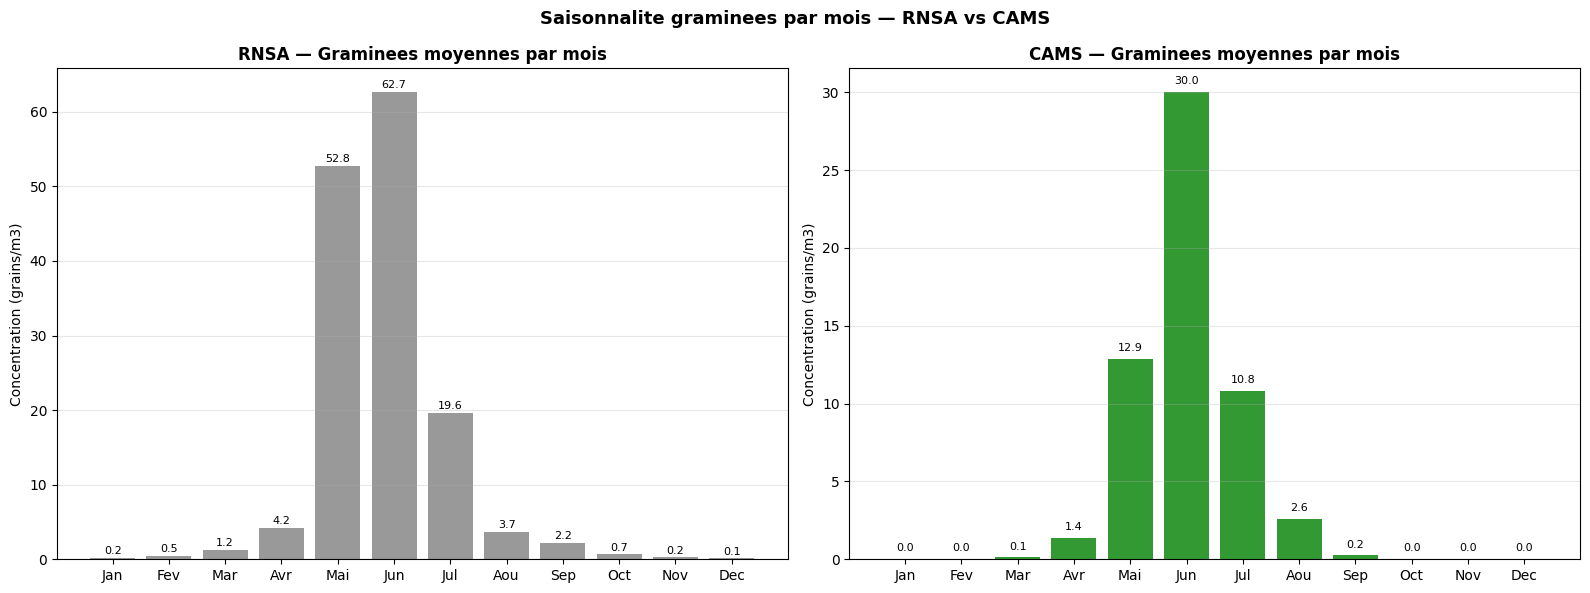

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Saisonnalite graminees par mois — RNSA vs CAMS', fontsize=13, fontweight='bold')

for idx, source in enumerate(['RNSA','CAMS']):
    df_s   = pollen_daily[pollen_daily['source']==source]
    saison = df_s.groupby('mois')['graminees'].mean()
    axes[idx].bar([mois_noms[m] for m in saison.index], saison.values,
                  color=colors_src[source], alpha=0.8)
    axes[idx].set_title(f'{source} — Graminees moyennes par mois', fontweight='bold')
    axes[idx].set_ylabel('Concentration (grains/m3)')
    axes[idx].grid(True, alpha=0.3, axis='y')
    for i, (m, v) in enumerate(saison.items()):
        axes[idx].text(i, v+0.5, f'{v:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/pollen_saisonnalite_complet.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Carte France 13 regions AASQA (juin — CAMS)

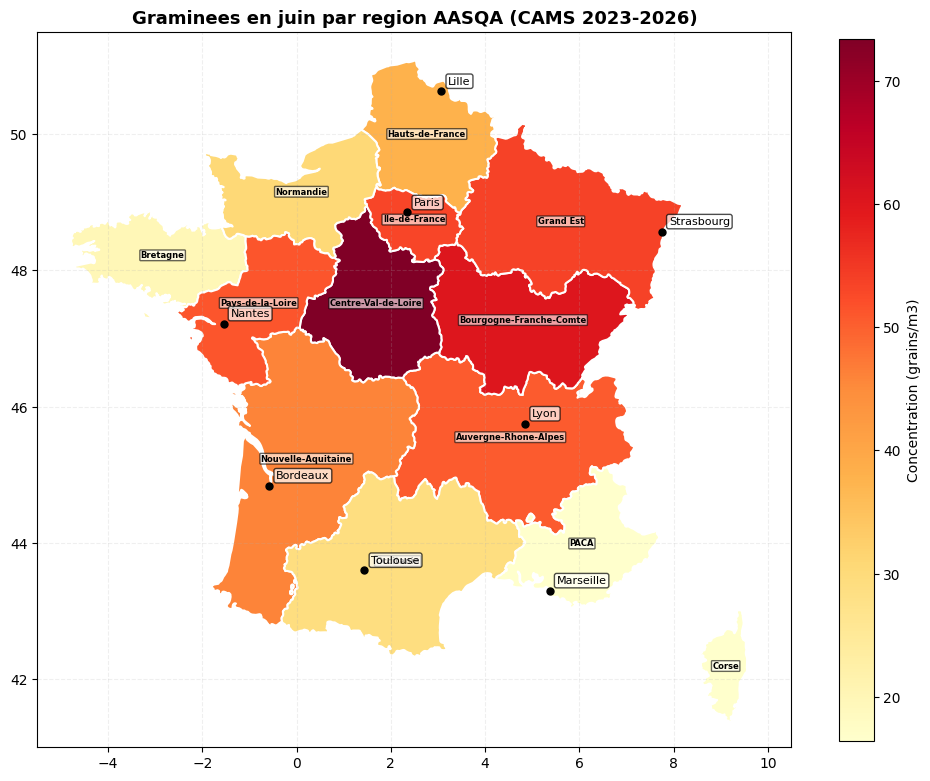

In [4]:
df_cams_brut = pd.read_csv('/Users/nellyta/Jedha/data/silver/J0_silver_cams_pollen_2023_2026.csv', low_memory=False)
df_cams_brut['date'] = pd.to_datetime(df_cams_brut['date'])

mapping_dept_region = {
    'Paris':'Ile-de-France','Hauts-de-Seine':'Ile-de-France',
    'Seine-Saint-Denis':'Ile-de-France',"Val-d'Oise":'Ile-de-France',
    'Yvelines':'Ile-de-France','Essonne':'Ile-de-France',
    'Seien-et-Marne':'Ile-de-France','Val-de-Marne':'Ile-de-France',
    'Nord':'Hauts-de-France','Pas-de-Calais':'Hauts-de-France',
    'Somme':'Hauts-de-France','Aisne':'Hauts-de-France','Oise':'Hauts-de-France',
    'Ardennes':'Grand Est','Meuse':'Grand Est','Meurthe-et-Moselle':'Grand Est',
    'Moselle':'Grand Est','Bas-Rhin':'Grand Est','Haute-Rhin':'Grand Est',
    'Vosges':'Grand Est','Marne':'Grand Est','Haute-Marne':'Grand Est','Aube':'Grand Est',
    'Seine-Maritime':'Normandie','Eure':'Normandie','Calvados':'Normandie',
    'Manche':'Normandie','Orne':'Normandie',
    'Finistere':'Bretagne',"Cotes-d'Armor":'Bretagne',
    'Morbihan':'Bretagne','Ille-et-Vilaine':'Bretagne',
    'Loire-Atlantique':'Pays-de-la-Loire','Vendee':'Pays-de-la-Loire',
    'Maine-et-Loire':'Pays-de-la-Loire','Sarthe':'Pays-de-la-Loire','Mayenne':'Pays-de-la-Loire',
    'Loiret':'Centre-Val-de-Loire','Loir-et-Cher':'Centre-Val-de-Loire',
    'Indre-et-Loire':'Centre-Val-de-Loire','Indre':'Centre-Val-de-Loire',
    'Cher':'Centre-Val-de-Loire','Eure-et-Loir':'Centre-Val-de-Loire',
    "Cote-d'Or":'Bourgogne-Franche-Comte','Nievre':'Bourgogne-Franche-Comte',
    'Saone-et-Loire':'Bourgogne-Franche-Comte','Yonne':'Bourgogne-Franche-Comte',
    'Doubs':'Bourgogne-Franche-Comte','Jura':'Bourgogne-Franche-Comte',
    'Haute-Saone':'Bourgogne-Franche-Comte','Territoire de Belfort':'Bourgogne-Franche-Comte',
    'Gironde':'Nouvelle-Aquitaine','Dordogne':'Nouvelle-Aquitaine',
    'Lot-et-Garonne':'Nouvelle-Aquitaine','Landes':'Nouvelle-Aquitaine',
    'Pyrenees-Atlantiques':'Nouvelle-Aquitaine','Charente':'Nouvelle-Aquitaine',
    'Charente-Maritime':'Nouvelle-Aquitaine','Deux-Sevres':'Nouvelle-Aquitaine',
    'Vienne':'Nouvelle-Aquitaine','Haute-Vienne':'Nouvelle-Aquitaine',
    'Correze':'Nouvelle-Aquitaine','Creuse':'Nouvelle-Aquitaine',
    'Haute-Garonne':'Occitanie','Hautes-Pyrenees':'Occitanie',
    'Ariege':'Occitanie','Pyrenees-Orientales':'Occitanie','Aude':'Occitanie',
    'Herault':'Occitanie','Gard':'Occitanie','Lozere':'Occitanie',
    'Aveyron':'Occitanie','Lot':'Occitanie','Tarn':'Occitanie',
    'Tarn-et-Garonne':'Occitanie','Gers':'Occitanie',
    'Rhone':'Auvergne-Rhone-Alpes','Ain':'Auvergne-Rhone-Alpes',
    'Loire':'Auvergne-Rhone-Alpes','Isere':'Auvergne-Rhone-Alpes',
    'Drome':'Auvergne-Rhone-Alpes','Ardeche':'Auvergne-Rhone-Alpes',
    'Savoie':'Auvergne-Rhone-Alpes','Haute-Savoie':'Auvergne-Rhone-Alpes',
    'Puy-de-Dome':'Auvergne-Rhone-Alpes','Allier':'Auvergne-Rhone-Alpes',
    'Haute-Loire':'Auvergne-Rhone-Alpes','Cantal':'Auvergne-Rhone-Alpes',
    'Bouches-du-Rhone':'PACA','Var':'PACA','Vaucluse':'PACA',
    'Alpes-Maritimes':'PACA','Alpes-de-Haute-Provence':'PACA','Hautes-Alpes':'PACA',
    'Haute-Corse':'Corse','Corse-du-Sud':'Corse',
}

regions = gpd.read_file('https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip')
regions_fr = regions[regions['admin']=='France'].copy()
regions_fr['name_clean'] = regions_fr['name'].str.normalize('NFKD').str.encode('ascii',errors='ignore').str.decode('ascii')
regions_fr['region'] = regions_fr['name_clean'].map(
    {k.encode('ascii','ignore').decode('ascii'):v for k,v in mapping_dept_region.items()})
regions_fr = regions_fr[regions_fr['region'].notna()]
regions_13  = regions_fr.dissolve(by='region').reset_index()

juin = df_cams_brut[df_cams_brut['date'].dt.month==6].copy()
gdf_juin = gpd.GeoDataFrame(juin, geometry=gpd.points_from_xy(juin['longitude'],juin['latitude']), crs='EPSG:4326')
joined = gpd.sjoin(gdf_juin, regions_13[['region','geometry']], how='left', predicate='within')
conc_region = joined.groupby('region')['graminees_conc'].mean().reset_index()
conc_region.columns = ['region','graminees_moy']
regions_13 = regions_13.merge(conc_region, on='region', how='left')

villes = {'Paris':(48.85,2.35),'Lyon':(45.75,4.85),'Marseille':(43.30,5.37),
          'Toulouse':(43.60,1.44),'Bordeaux':(44.84,-0.58),'Nantes':(47.22,-1.55),
          'Strasbourg':(48.57,7.75),'Lille':(50.63,3.07)}

fig, ax = plt.subplots(figsize=(10, 12))
regions_13.plot(column='graminees_moy', cmap='YlOrRd', linewidth=1.5,
                edgecolor='white', ax=ax, legend=True,
                missing_kwds={'color':'lightgray'},
                legend_kwds={'label':'Concentration (grains/m3)', 'shrink':0.6})
for _, row in regions_13.iterrows():
    centroid = row['geometry'].centroid
    ax.annotate(row['region'], xy=(centroid.x,centroid.y),
                ha='center', fontsize=6, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.6))
for ville, (lat, lon) in villes.items():
    ax.plot(lon, lat, 'o', color='black', markersize=5, zorder=10)
    ax.annotate(ville, xy=(lon,lat), xytext=(5,5), textcoords='offset points',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
ax.set_title('Graminees en juin par region AASQA (CAMS 2023-2026)', fontsize=13, fontweight='bold')
ax.set_xlim(-5.5, 10.5)
ax.set_ylim(41.0, 51.5)
ax.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/carte_graminees_complet.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation meteo / graminees — RNSA vs CAMS

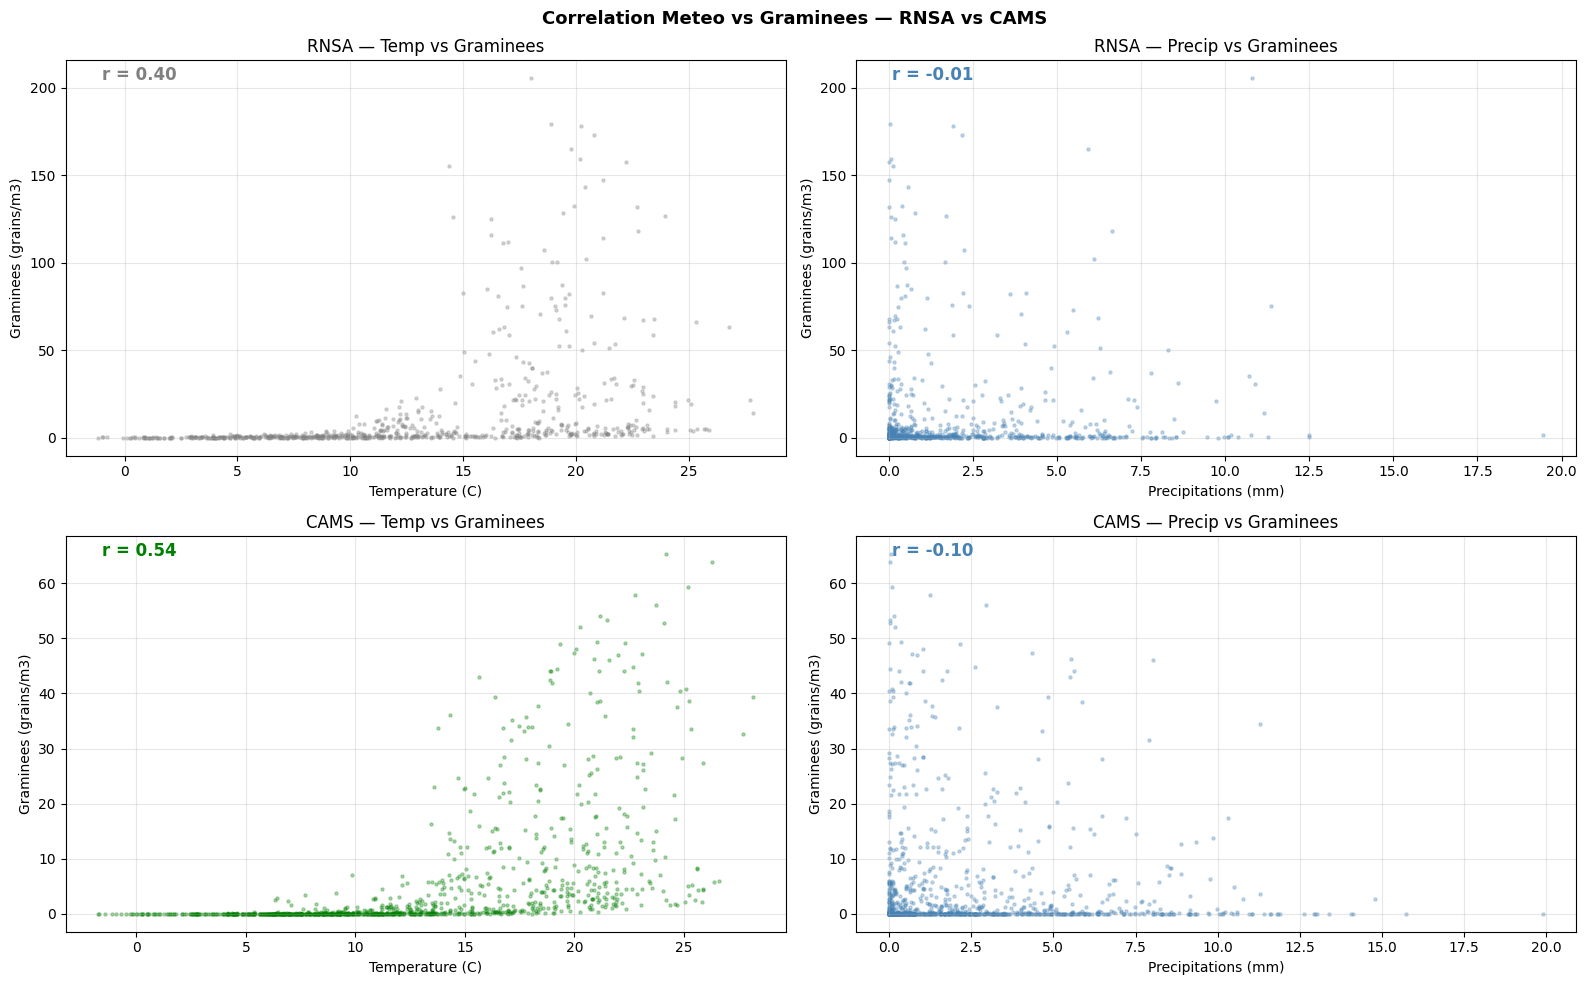

RNSA — Corr temp : 0.402 | Corr precip : -0.013
CAMS — Corr temp : 0.537 | Corr precip : -0.100


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Correlation Meteo vs Graminees — RNSA vs CAMS', fontsize=13, fontweight='bold')

for idx, source in enumerate(['RNSA','CAMS']):
    df_s = merged[merged['source']==source].dropna(subset=['temp_moy','precip'])
    corr_t = df_s['temp_moy'].corr(df_s['graminees'])
    corr_p = df_s['precip'].corr(df_s['graminees'])

    axes[idx,0].scatter(df_s['temp_moy'], df_s['graminees'], alpha=0.3, color=colors_src[source], s=5)
    axes[idx,0].set_xlabel('Temperature (C)')
    axes[idx,0].set_ylabel('Graminees (grains/m3)')
    axes[idx,0].set_title(f'{source} — Temp vs Graminees')
    axes[idx,0].grid(True, alpha=0.3)
    axes[idx,0].annotate(f'r = {corr_t:.2f}', xy=(0.05,0.95), xycoords='axes fraction',
                         fontsize=12, fontweight='bold', color=colors_src[source])

    axes[idx,1].scatter(df_s['precip'], df_s['graminees'], alpha=0.3, color='steelblue', s=5)
    axes[idx,1].set_xlabel('Precipitations (mm)')
    axes[idx,1].set_ylabel('Graminees (grains/m3)')
    axes[idx,1].set_title(f'{source} — Precip vs Graminees')
    axes[idx,1].grid(True, alpha=0.3)
    axes[idx,1].annotate(f'r = {corr_p:.2f}', xy=(0.05,0.95), xycoords='axes fraction',
                         fontsize=12, fontweight='bold', color='steelblue')

plt.tight_layout()
plt.savefig('/Users/nellyta/Jedha/notebooks/correlation_complet.png', dpi=150, bbox_inches='tight')
plt.show()

for source in ['RNSA','CAMS']:
    df_s = merged[merged['source']==source].dropna(subset=['temp_moy','precip'])
    print(f'{source} — Corr temp : {df_s["temp_moy"].corr(df_s["graminees"]):.3f} | Corr precip : {df_s["precip"].corr(df_s["graminees"]):.3f}')

## 5. Random Forest Regressor — avec météo
> Features : temp_moy, temp_max, temp_min, precip, wind, mois, jour_annee, saison_allergies, source_encoded

In [6]:
features_meteo = ['temp_moy','temp_max','temp_min','precip','wind',
                  'mois','jour_annee','saison_allergies','source_encoded']

def run_rf(df, features, label):
    df = df.copy().sort_values('date').reset_index(drop=True)
    df['gram_next'] = df['graminees'].shift(-1)
    df = df.dropna(subset=['gram_next']+features)
    if len(df) < 20:
        print(f'  {label} : pas assez de donnees')
        return None,None,None,None
    X = df[features]
    y = df['gram_next']
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    rf = RandomForestRegressor(n_estimators=100,random_state=42)
    rf.fit(X_train,y_train)
    y_pred = rf.predict(X_test)
    r2   = r2_score(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    print(f'  {label:<30} R2={r2:.3f} | RMSE={rmse:.3f} | n={len(df)}')
    return y_test,y_pred,r2,rmse

print('=== RF AVEC METEO ===')
resultats_meteo = {}
y_t,y_p,r2,rmse = run_rf(merged, features_meteo, 'Toutes annees 2021-2026')
if r2 is not None:
    resultats_meteo['toutes'] = {'y_test':y_t,'y_pred':y_p,'r2':r2,'rmse':rmse,'label':'Toutes annees 2021-2026','color':'purple'}

colors_an = {2021:'steelblue',2022:'coral',2023:'mediumseagreen',2024:'mediumpurple',2025:'orange',2026:'red'}
for annee in sorted(merged['annee'].unique()):
    df_an = merged[merged['annee']==annee]
    y_t,y_p,r2_,rmse_ = run_rf(df_an, features_meteo, f'Annee {annee}')
    if r2_ is not None:
        resultats_meteo[annee] = {'y_test':y_t,'y_pred':y_p,'r2':r2_,'rmse':rmse_,'label':f'Annee {annee}','color':colors_an.get(annee,'purple')}

=== RF AVEC METEO ===
  Toutes annees 2021-2026        R2=0.783 | RMSE=7.823 | n=1749
  Annee 2021                     R2=0.945 | RMSE=4.060 | n=364
  Annee 2022                     R2=0.955 | RMSE=4.843 | n=364
  Annee 2023                     R2=0.859 | RMSE=6.001 | n=137
  Annee 2024                     R2=0.349 | RMSE=3.342 | n=365
  Annee 2025                     R2=0.869 | RMSE=2.668 | n=364
  Annee 2026                     R2=0.976 | RMSE=1.603 | n=150


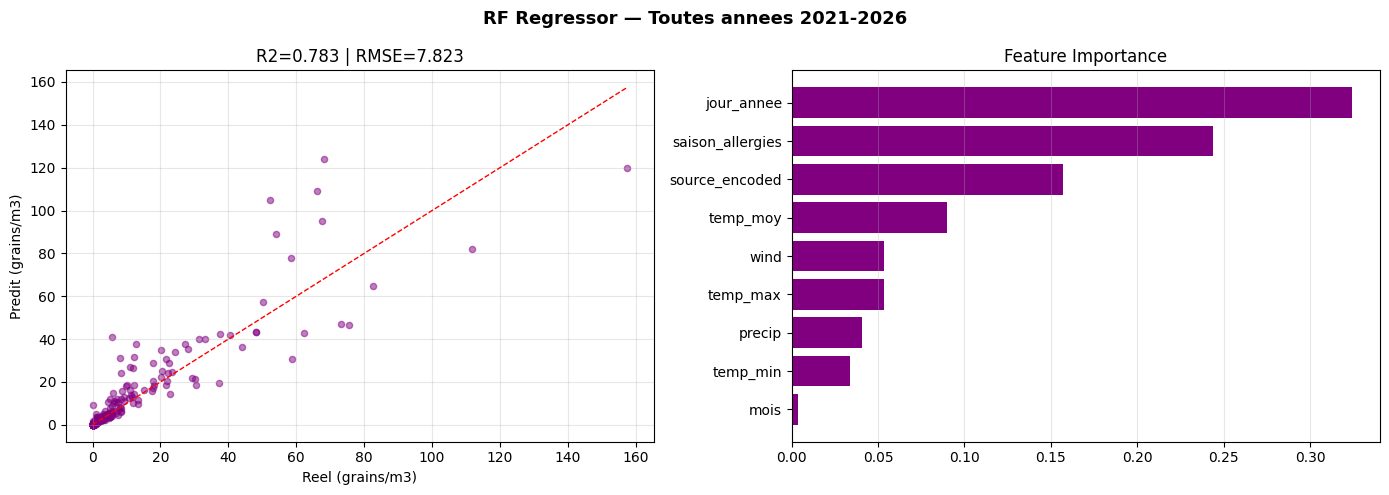

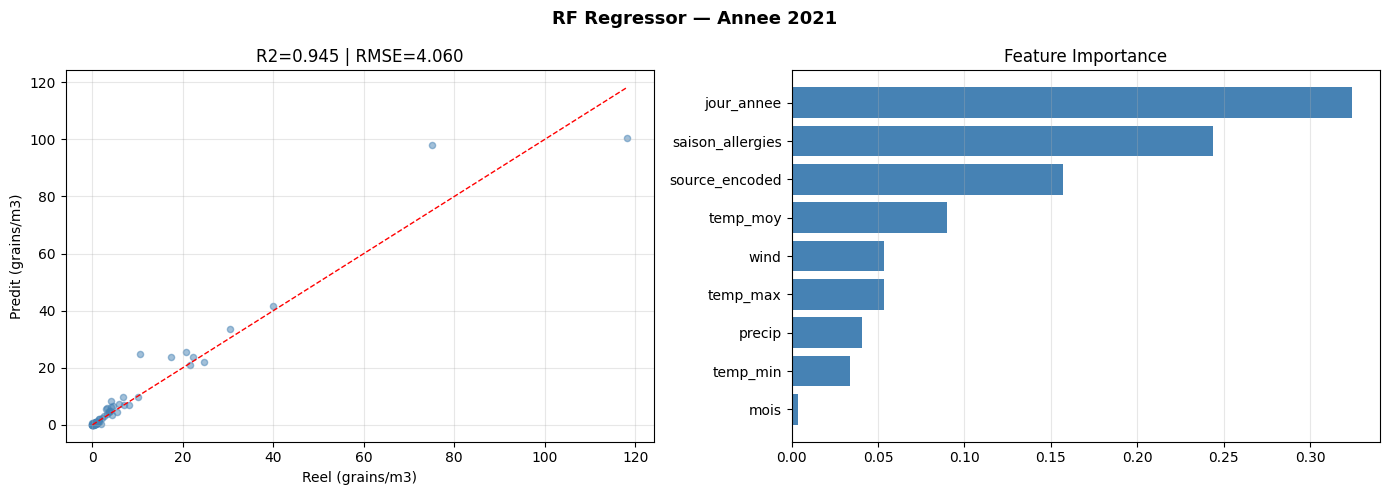

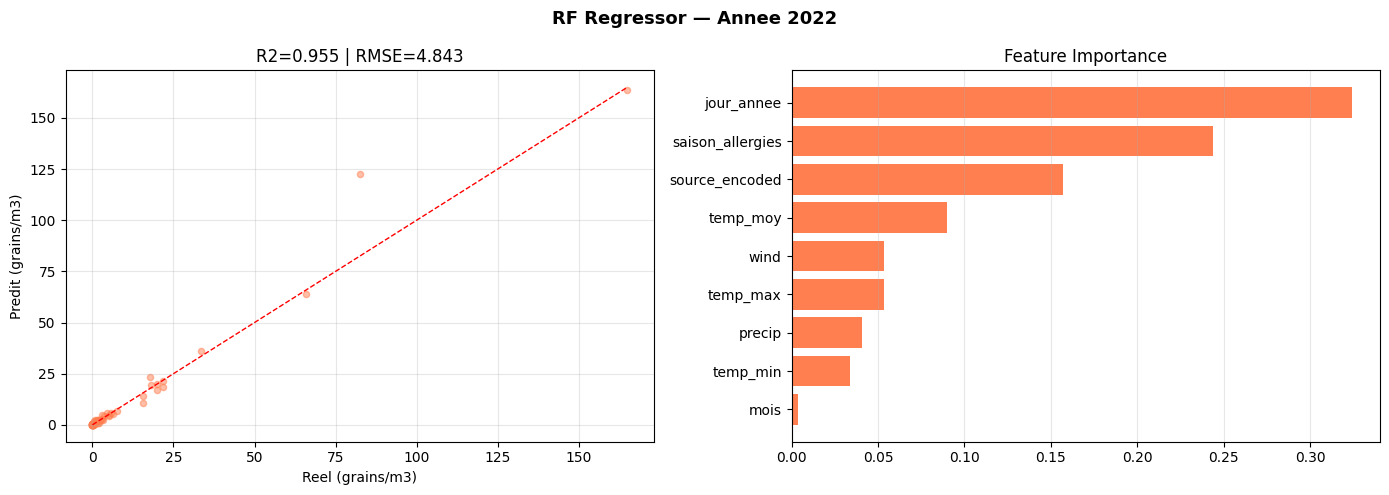

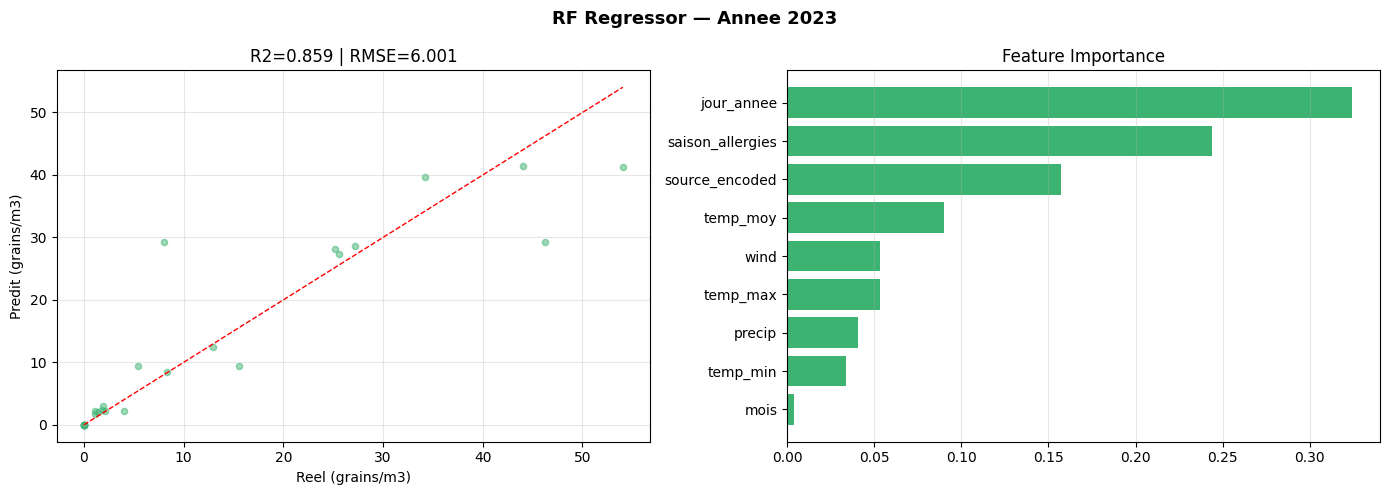

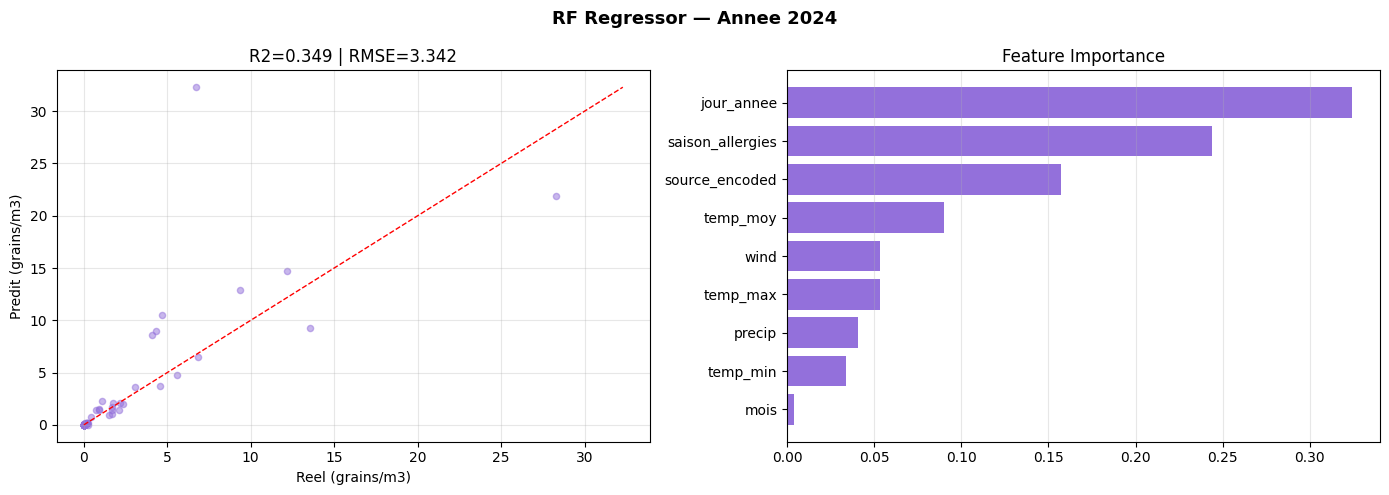

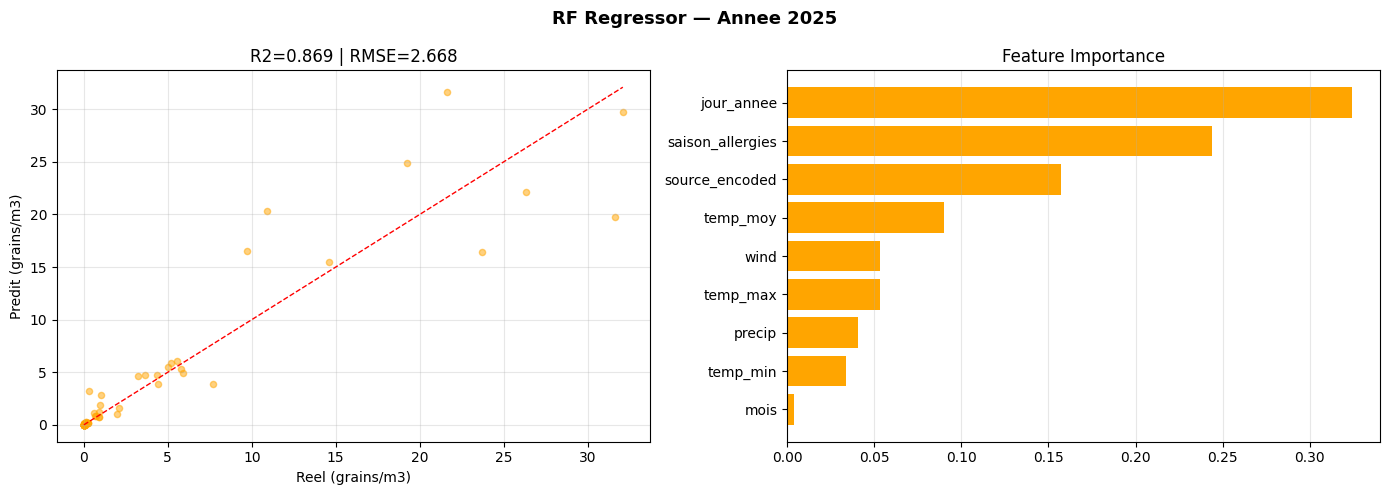

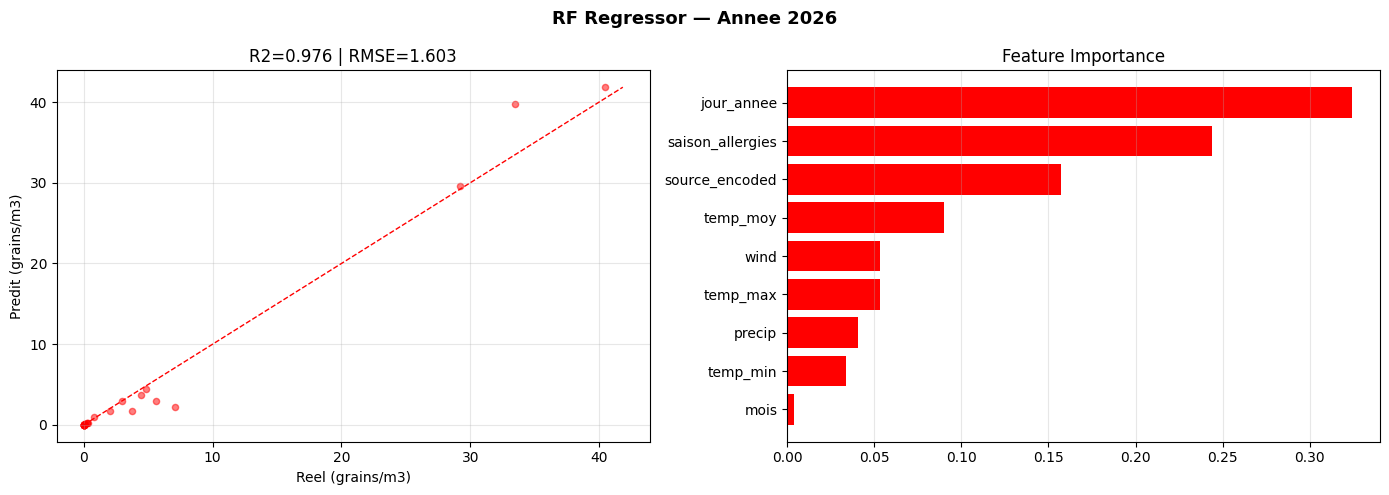

In [7]:
def plot_rf_bloc(res, features):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"RF Regressor — {res['label']}", fontsize=13, fontweight='bold')

    axes[0].scatter(res['y_test'], res['y_pred'], alpha=0.5, color=res['color'], s=20)
    max_val = max(float(res['y_test'].max()), float(res['y_pred'].max()))
    axes[0].plot([0,max_val],[0,max_val],'r--',linewidth=1)
    axes[0].set_xlabel('Reel (grains/m3)')
    axes[0].set_ylabel('Predit (grains/m3)')
    axes[0].set_title(f"R2={res['r2']:.3f} | RMSE={res['rmse']:.3f}")
    axes[0].grid(True, alpha=0.3)

    df_tmp = merged.copy().sort_values('date').reset_index(drop=True)
    df_tmp['gram_next'] = df_tmp['graminees'].shift(-1)
    df_tmp = df_tmp.dropna(subset=['gram_next']+features)
    rf_tmp = RandomForestRegressor(n_estimators=100,random_state=42)
    rf_tmp.fit(df_tmp[features], df_tmp['gram_next'])
    imp = pd.DataFrame({'feature':features,'importance':rf_tmp.feature_importances_}).sort_values('importance',ascending=True)
    axes[1].barh(imp['feature'], imp['importance'], color=res['color'])
    axes[1].set_title('Feature Importance')
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    fname = res['label'].replace(' ','_').replace('-','_')
    plt.savefig(f"/Users/nellyta/Jedha/notebooks/rf_complet_{fname}.png", dpi=150, bbox_inches='tight')
    plt.show()

for key in resultats_meteo:
    plot_rf_bloc(resultats_meteo[key], features_meteo)

## 6. Analyse 2024 — Saison atypique
> **Contexte** : Le R² de 2024 (0.349) est anormalement bas. On cherche à comprendre pourquoi.

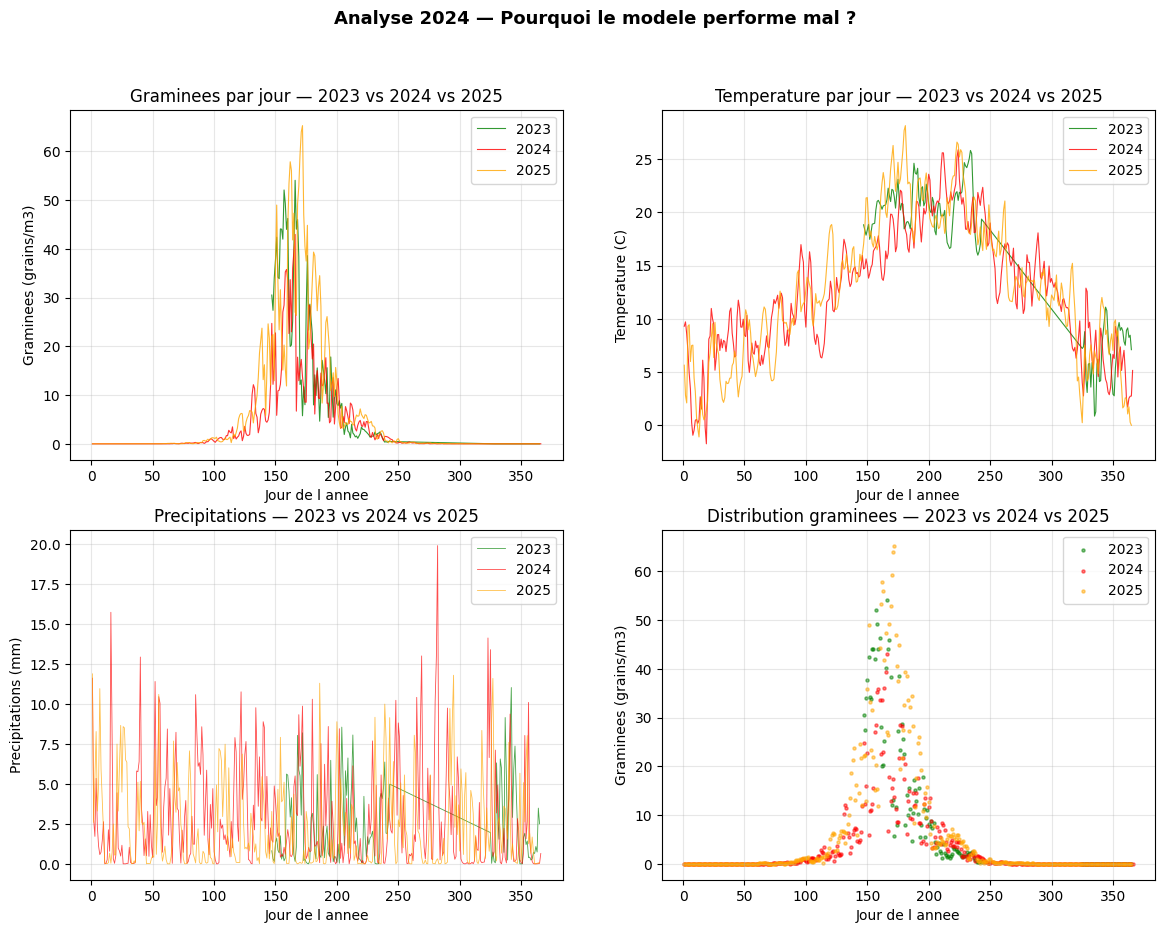

Stats par annee :
  2023 — gram_moy=10.33 | gram_max=54.05 | temp_moy=16.4C
  2024 — gram_moy=3.49 | gram_max=42.94 | temp_moy=12.5C
  2025 — gram_moy=5.92 | gram_max=65.26 | temp_moy=12.9C

Stats precipitations :
  2023 — precip_moy=2.39mm | precip_max=11.03mm | nb_jours_pluie=82
  2024 — precip_moy=2.87mm | precip_max=19.91mm | nb_jours_pluie=220
  2025 — precip_moy=2.30mm | precip_max=11.88mm | nb_jours_pluie=193

Conclusion :
  2024 a des concentrations 3x inferieures a 2023 (3.49 vs 10.33 grains/m3)
  Temperature plus basse (12.5C vs 16.4C en 2023)
  Le modele entraine sur les autres annees surestime les concentrations de 2024
  -> Annee meteorologiquement atypique — limite attendue du modele


In [8]:
df_2024 = merged[merged['annee']==2024].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse 2024 — Pourquoi le modele performe mal ?', fontsize=13, fontweight='bold')

# 1. Graminees 2023 vs 2024 vs 2025
for annee, color in [(2023,'green'),(2024,'red'),(2025,'orange')]:
    df_an = merged[merged['annee']==annee]
    axes[0,0].plot(df_an['jour_annee'], df_an['graminees'],
                   label=str(annee), color=color, linewidth=0.8, alpha=0.8)
axes[0,0].set_title('Graminees par jour — 2023 vs 2024 vs 2025')
axes[0,0].set_xlabel('Jour de l annee')
axes[0,0].set_ylabel('Graminees (grains/m3)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Temperature 2023 vs 2024 vs 2025
for annee, color in [(2023,'green'),(2024,'red'),(2025,'orange')]:
    df_an = merged[merged['annee']==annee].dropna(subset=['temp_moy'])
    axes[0,1].plot(df_an['jour_annee'], df_an['temp_moy'],
                   label=str(annee), color=color, linewidth=0.8, alpha=0.8)
axes[0,1].set_title('Temperature par jour — 2023 vs 2024 vs 2025')
axes[0,1].set_xlabel('Jour de l annee')
axes[0,1].set_ylabel('Temperature (C)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Precipitations 2023 vs 2024 vs 2025
for annee, color in [(2023,'green'),(2024,'red'),(2025,'orange')]:
    df_an = merged[merged['annee']==annee].dropna(subset=['precip'])
    axes[1,0].plot(df_an['jour_annee'], df_an['precip'],
                   label=str(annee), color=color, linewidth=0.6, alpha=0.7)
axes[1,0].set_title('Precipitations — 2023 vs 2024 vs 2025')
axes[1,0].set_xlabel('Jour de l annee')
axes[1,0].set_ylabel('Precipitations (mm)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Distribution graminees 2023 vs 2024 vs 2025
for annee, color in [(2023,'green'),(2024,'red'),(2025,'orange')]:
    df_an = merged[merged['annee']==annee]
    axes[1,1].scatter(df_an['jour_annee'], df_an['graminees'],
                      label=str(annee), color=color, s=5, alpha=0.5)
axes[1,1].set_title('Distribution graminees — 2023 vs 2024 vs 2025')
axes[1,1].set_xlabel('Jour de l annee')
axes[1,1].set_ylabel('Graminees (grains/m3)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.savefig('/Users/nellyta/Jedha/notebooks/analyse_2024.png', dpi=150, bbox_inches='tight')
plt.show()

print('Stats par annee :')
for annee in [2023, 2024, 2025]:
    df_an = merged[merged['annee']==annee]
    print(f'  {annee} — gram_moy={df_an["graminees"].mean():.2f} | gram_max={df_an["graminees"].max():.2f} | temp_moy={df_an["temp_moy"].mean():.1f}C')

print()
print('Stats precipitations :')
for annee in [2023, 2024, 2025]:
    df_an = merged[merged['annee']==annee].dropna(subset=['precip'])
    print(f'  {annee} — precip_moy={df_an["precip"].mean():.2f}mm | precip_max={df_an["precip"].max():.2f}mm | nb_jours_pluie={len(df_an[df_an["precip"]>1])}')

print()
print('Conclusion :')
print('  2024 a des concentrations 3x inferieures a 2023 (3.49 vs 10.33 grains/m3)')
print('  Temperature plus basse (12.5C vs 16.4C en 2023)')
print('  Le modele entraine sur les autres annees surestime les concentrations de 2024')
print('  -> Annee meteorologiquement atypique — limite attendue du modele')

## 7. Synthese

In [9]:
print('=' * 65)
print('SYNTHESE EDA POLLEN & METEO 2021-2026')
print('=' * 65)
print(f'  Periode   : {merged.date.min().date()} -> {merged.date.max().date()}')
print(f'  RNSA      : {(pollen_daily.source=="RNSA").sum()} jours')
print(f'  CAMS      : {(pollen_daily.source=="CAMS").sum()} jours')
print(f'  Regions   : {df_meteo["region"].nunique()}')
print()
print('PICS PAR TAXON')
for taxon in taxons_list:
    mois_pic = pollen_daily.groupby('mois')[taxon].mean().idxmax()
    val_max  = pollen_daily[taxon].max()
    print(f'  {taxon:<12} -> pic en {mois_noms[mois_pic]}, max = {val_max:.1f} grains/m3')
print()
print('CORRELATIONS METEO / GRAMINEES')
for source in ['RNSA','CAMS']:
    df_s = merged[merged['source']==source].dropna(subset=['temp_moy','precip'])
    print(f'  {source} — Temp : {df_s["temp_moy"].corr(df_s["graminees"]):.3f} | Precip : {df_s["precip"].corr(df_s["graminees"]):.3f}')
print()
print('RF AVEC METEO — R2 PAR ANNEE')
for k,v in resultats_meteo.items():
    note = '-- annee atypique' if k == 2024 else '-- donnees partielles' if k == 2026 else ''
    print(f'  {v["label"]:<30} R2={v["r2"]:.3f} | RMSE={v["rmse"]:.3f} {note}')
print()
print('FEATURES ML RETENUES POUR J4')
print('  jour_annee (0.33)      -> saisonnalite principale')
print('  saison_allergies (0.25) -> flag avril-juillet')
print('  source_encoded (0.15)  -> correction biais RNSA/CAMS')
print('  temp_moy (0.09)        -> meteo principale')

SYNTHESE EDA POLLEN & METEO 2021-2026
  Periode   : 2021-01-01 -> 2026-06-01
  RNSA      : 730 jours
  CAMS      : 1021 jours
  Regions   : 13

PICS PAR TAXON
  graminees    -> pic en Jun, max = 205.3 grains/m3
  bouleau      -> pic en Avr, max = 300.4 grains/m3
  aulne        -> pic en Fev, max = 379.1 grains/m3
  ambroisie    -> pic en Sep, max = 31.3 grains/m3
  armoise      -> pic en Aou, max = 6.6 grains/m3
  olivier      -> pic en Mai, max = 33.2 grains/m3

CORRELATIONS METEO / GRAMINEES
  RNSA — Temp : 0.402 | Precip : -0.013
  CAMS — Temp : 0.537 | Precip : -0.100

RF AVEC METEO — R2 PAR ANNEE
  Toutes annees 2021-2026        R2=0.783 | RMSE=7.823 
  Annee 2021                     R2=0.945 | RMSE=4.060 
  Annee 2022                     R2=0.955 | RMSE=4.843 
  Annee 2023                     R2=0.859 | RMSE=6.001 
  Annee 2024                     R2=0.349 | RMSE=3.342 -- annee atypique
  Annee 2025                     R2=0.869 | RMSE=2.668 
  Annee 2026                     R2=0.